In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import zscore

# Load your dataset
df = pd.read_csv('Sales Report.csv')  # Updated to your file

/tmp/ipykernel_73284/2570560392.py:10: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Sales Report.csv')  # Updated to your file


In [6]:
# Display first 10 rows
print("First 10 rows:")
print(df.head(10))

# Display last 10 rows
print("\nLast 10 rows:")
print(df.tail(10))

# Dataset shape
print(f"\nDataset shape: {df.shape} (rows, columns)")

# Identify attribute types
numerical_attrs = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_attrs = df.select_dtypes(include=['object']).columns.tolist()
datetime_attrs = df.select_dtypes(include=['datetime']).columns.tolist()  # If any

print(f"\nNumerical attributes: {numerical_attrs}")
print(f"Categorical attributes: {categorical_attrs}")
print(f"Date/time attributes: {datetime_attrs}")

First 10 rows:
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   
5      5  404-1490984-4578765  04-30-22                       Shipped   
6      6  408-5748499-6859555  04-30-22                       Shipped   
7      7  406-7807733-3785945  04-30-22  Shipped - Delivered to Buyer   
8      8  407-5443024-5233168  04-30-22                     Cancelled   
9      9  402-4393761-0311520  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style                  SKU  \
0   Merchant      Amazon.in           Standard   SET389       SET389-KR-NP-S   
1   Merchant      Ama

                             Attribute     Type  Missing %  Unique Values
index                            index    int64   0.000000         128975
Order ID                      Order ID   object   0.000000         120378
Date                              Date   object   0.000000             91
Status                          Status   object   0.000000             13
Fulfilment                  Fulfilment   object   0.000000              2
Sales Channel           Sales Channel    object   0.000000              2
ship-service-level  ship-service-level   object   0.000000              2
Style                            Style   object   0.000000           1377
SKU                                SKU   object   0.000000           7195
Category                      Category   object   0.000000              9
Size                              Size   object   0.000000             11
ASIN                              ASIN   object   0.000000           7190
Courier Status          Courier Status

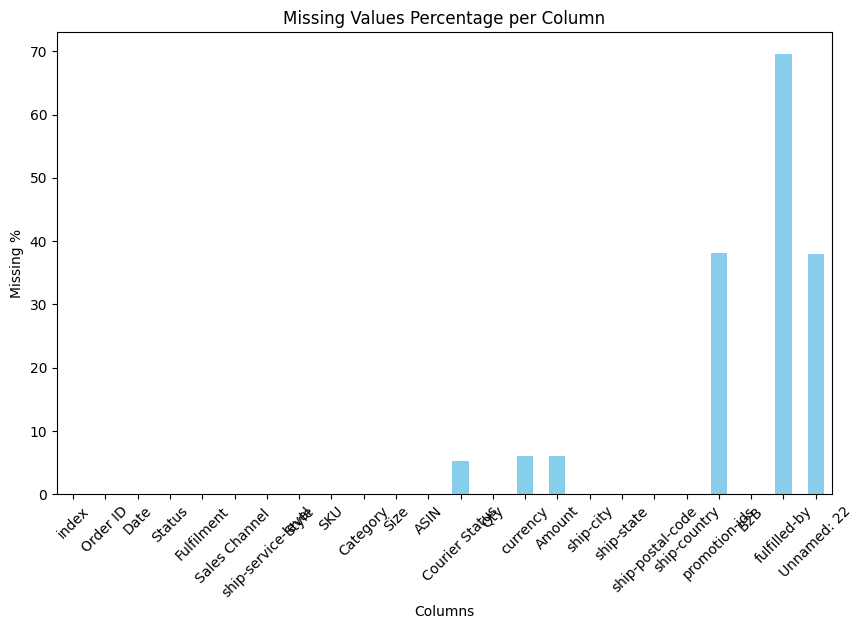

In [7]:
# Create profiling table
profiling = pd.DataFrame({
    'Attribute': df.columns,
    'Type': df.dtypes,
    'Missing %': (df.isnull().sum() / len(df)) * 100,
    'Unique Values': df.nunique()
})
print(profiling)

# Visualization: Bar chart of missing values per column
plt.figure(figsize=(10, 6))
profiling['Missing %'].plot(kind='bar', color='skyblue')
plt.title('Missing Values Percentage per Column')
plt.xlabel('Columns')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.show()

Descriptive Statistics:
               index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  121180.000000     128942.000000
mean    64487.000000       0.904431     648.561465     463966.236509
std     37232.019822       0.313354     281.211687     191476.764941
min         0.000000       0.000000       0.000000     110001.000000
25%     32243.500000       1.000000     449.000000     382421.000000
50%     64487.000000       1.000000     605.000000     500033.000000
75%     96730.500000       1.000000     788.000000     600024.000000
max    128974.000000      15.000000    5584.000000     989898.000000
Mode for Order ID: 171-5057375-2831560
Mode for Date: 05-03-22
Mode for Status: Shipped
Mode for Fulfilment: Amazon
Mode for Sales Channel : Amazon.in
Mode for ship-service-level: Expedited
Mode for Style: JNE3797
Mode for SKU: JNE3797-KR-L
Mode for Category: Set
Mode for Size: M
Mode for ASIN: B09SDXFFQ1
Mode for Courier Status: Shipped
Mode for curren

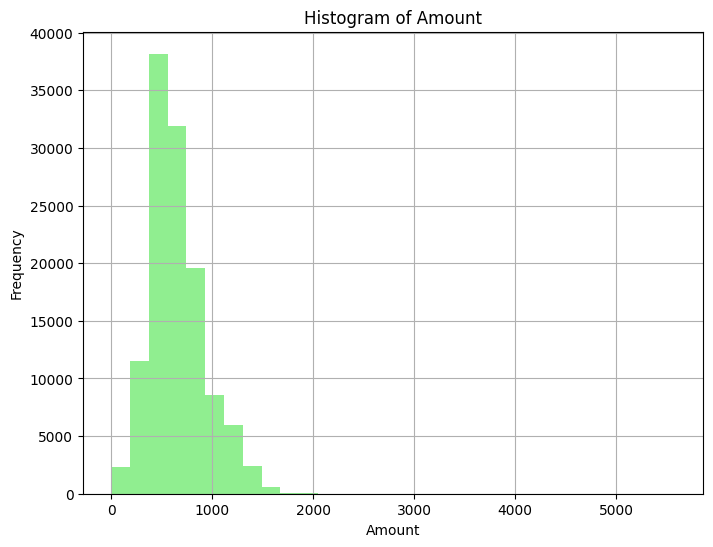

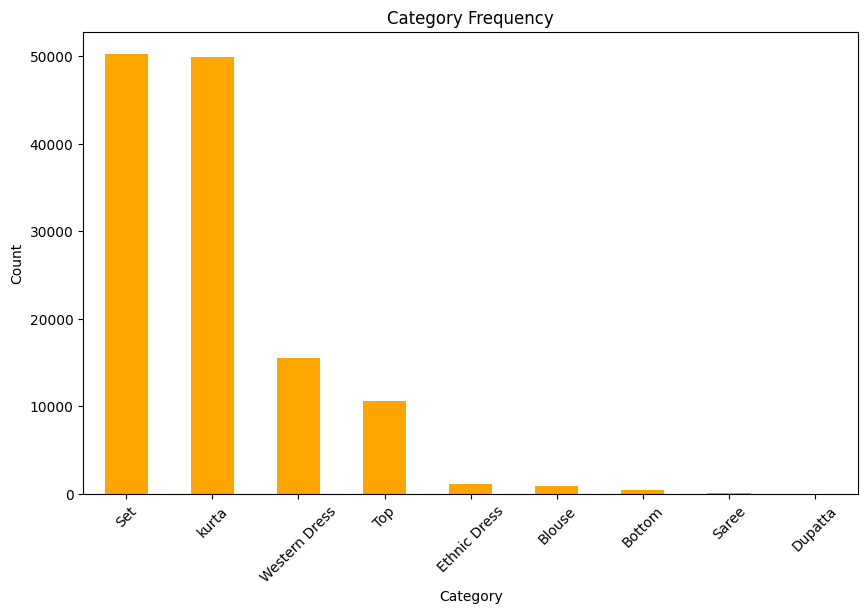

In [8]:
# Descriptive stats for numerical columns
print("Descriptive Statistics:")
print(df.describe())

# For categorical, mode
for col in categorical_attrs:
    print(f"Mode for {col}: {df[col].mode()[0]}")

# Visualization: Histogram of Amount
plt.figure(figsize=(8, 6))
df['Amount'].hist(bins=30, color='lightgreen')
plt.title('Histogram of Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

# Visualization: Bar chart of Category frequency
plt.figure(figsize=(10, 6))
df['Category'].value_counts().plot(kind='bar', color='orange')
plt.title('Category Frequency')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

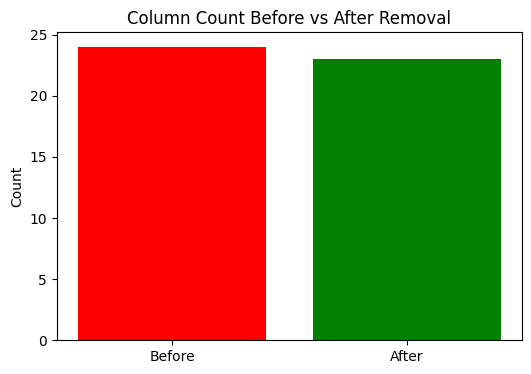

In [9]:
# Assume irrelevant columns like 'Order ID', 'URL', 'Tracking Code' (adjust based on your dataset)
irrelevant_cols = ['Order ID', 'URL', 'Tracking Code']  # Example; customize
df_clean = df.drop(columns=[col for col in irrelevant_cols if col in df.columns])

# Visualization: Column count before vs after
before = len(df.columns)
after = len(df_clean.columns)
plt.figure(figsize=(6, 4))
plt.bar(['Before', 'After'], [before, after], color=['red', 'green'])
plt.title('Column Count Before vs After Removal')
plt.ylabel('Count')
plt.show()

df = df_clean  # Update df

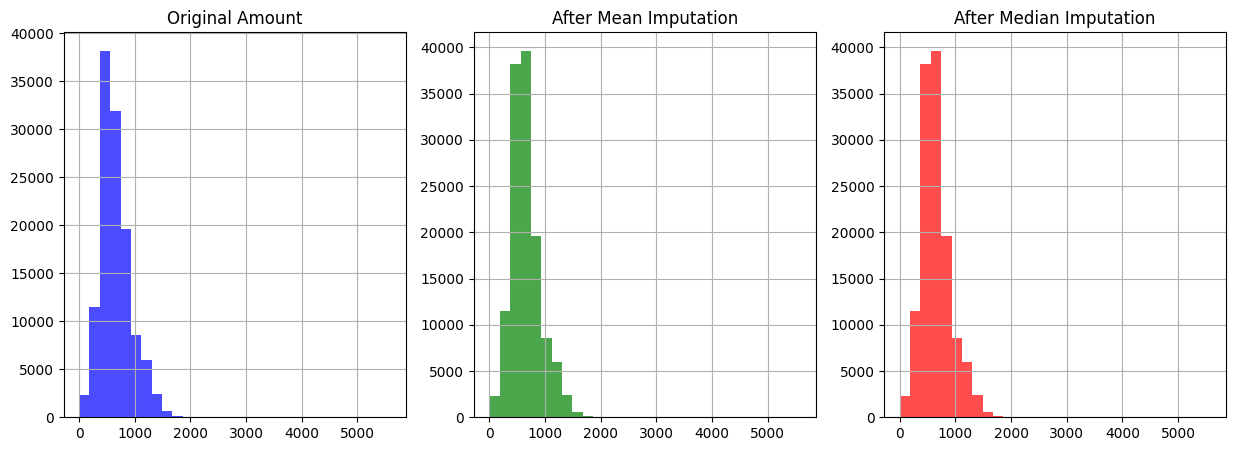

In [10]:
# Numerical: Mean and Median Imputation (compare on Amount)
df['Amount_mean'] = df['Amount'].fillna(df['Amount'].mean())
df['Amount_median'] = df['Amount'].fillna(df['Amount'].median())

# Categorical: Mode Imputation (on Category)
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

# Visualization: Histogram before & after imputation (for Amount)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['Amount'].hist(bins=30, ax=axes[0], color='blue', alpha=0.7)
axes[0].set_title('Original Amount')
df['Amount_mean'].hist(bins=30, ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('After Mean Imputation')
df['Amount_median'].hist(bins=30, ax=axes[2], color='red', alpha=0.7)
axes[2].set_title('After Median Imputation')
plt.show()

# Choose one (e.g., median) and update
df['Amount'] = df['Amount_median']
df.drop(columns=['Amount_mean', 'Amount_median'], inplace=True)

Number of duplicates: 0


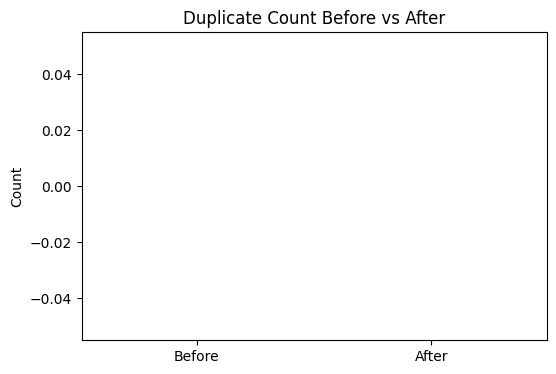

In [11]:
# Identify duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicates: {duplicates}")

# Remove duplicates
df = df.drop_duplicates()

# Visualization: Duplicate count before & after
plt.figure(figsize=(6, 4))
plt.bar(['Before', 'After'], [duplicates, 0], color=['purple', 'yellow'])
plt.title('Duplicate Count Before vs After')
plt.ylabel('Count')
plt.show()

Outliers detected via Z-Score: 946


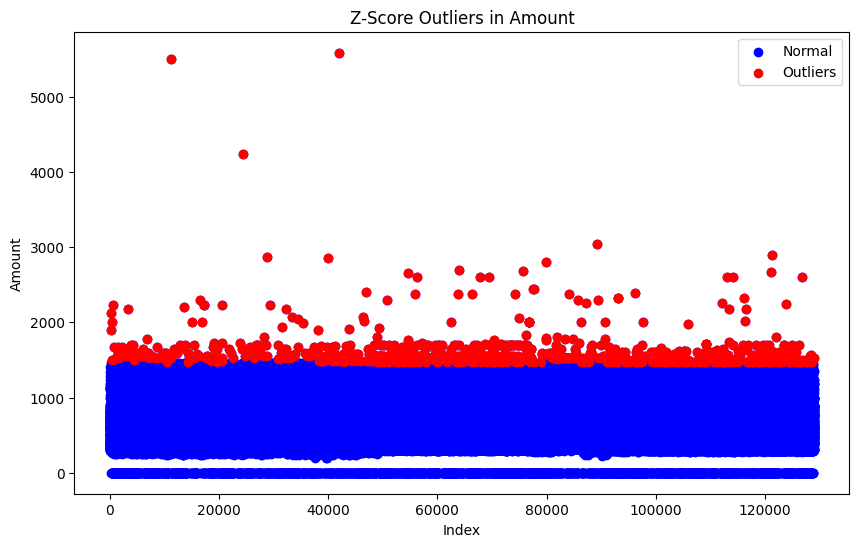

In [12]:
# Z-Score for Amount (threshold ±3)
z_scores = zscore(df['Amount'])
outliers_z = np.abs(z_scores) > 3
print(f"Outliers detected via Z-Score: {outliers_z.sum()}")

# Visualization: Scatter plot with outliers highlighted (assuming index as x)
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['Amount'], color='blue', label='Normal')
plt.scatter(df.index[outliers_z], df['Amount'][outliers_z], color='red', label='Outliers')
plt.title('Z-Score Outliers in Amount')
plt.xlabel('Index')
plt.ylabel('Amount')
plt.legend()
plt.show()

Outliers detected via IQR: 4177


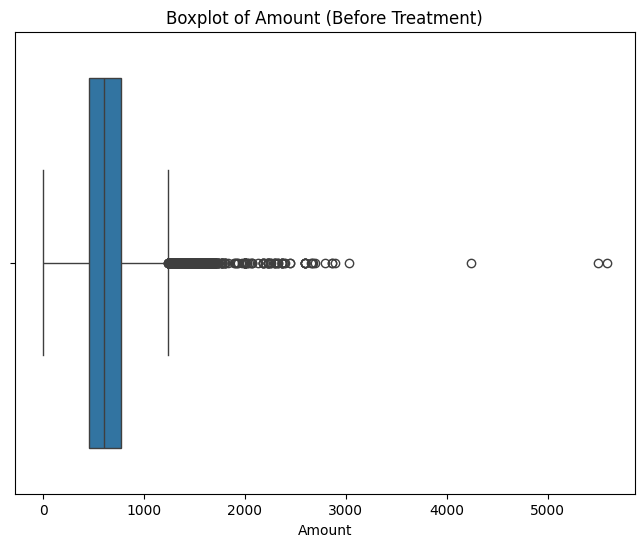

In [13]:
# IQR for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = (df['Amount'] < (Q1 - 1.5 * IQR)) | (df['Amount'] > (Q3 + 1.5 * IQR))
print(f"Outliers detected via IQR: {outliers_iqr.sum()}")

# Visualization: Boxplot before treatment
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Amount (Before Treatment)')
plt.show()

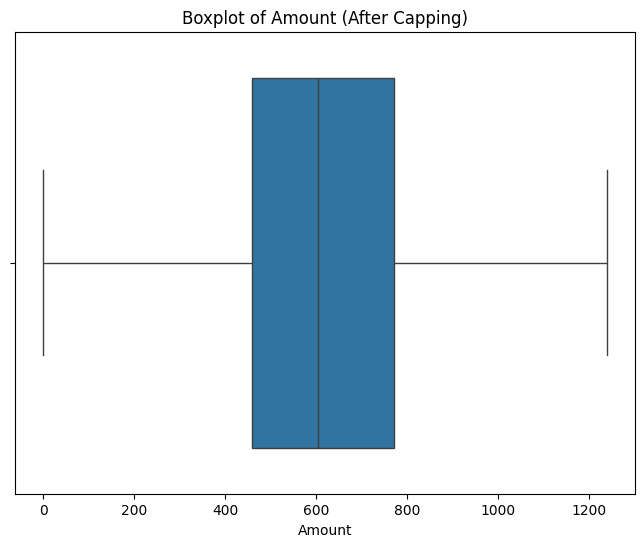

In [14]:
# Capping using IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Amount'] = np.clip(df['Amount'], lower_bound, upper_bound)

# Visualization: Boxplot after treatment
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Amount (After Capping)')
plt.show()

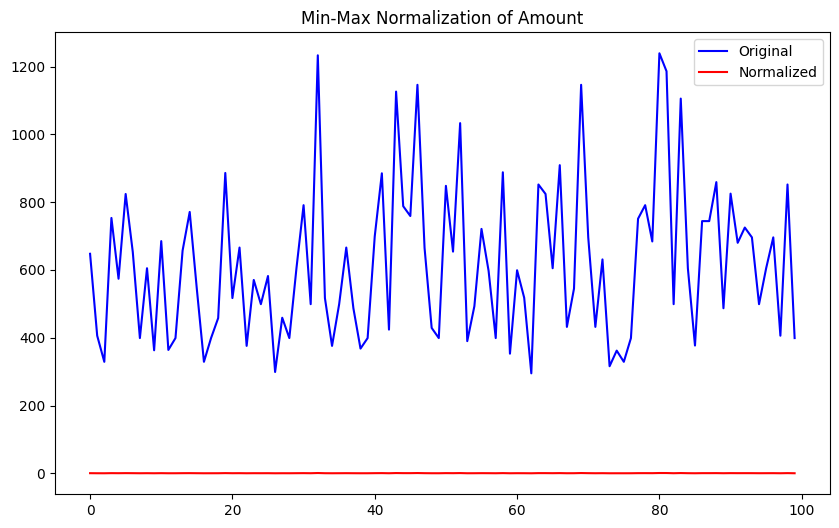

In [15]:
# Apply on Amount
scaler_minmax = MinMaxScaler()
df['Amount_normalized'] = scaler_minmax.fit_transform(df[['Amount']])

# Visualization: Line plot before & after (sample first 100 rows)
plt.figure(figsize=(10, 6))
plt.plot(df['Amount'][:100], label='Original', color='blue')
plt.plot(df['Amount_normalized'][:100], label='Normalized', color='red')
plt.title('Min-Max Normalization of Amount')
plt.legend()
plt.show()

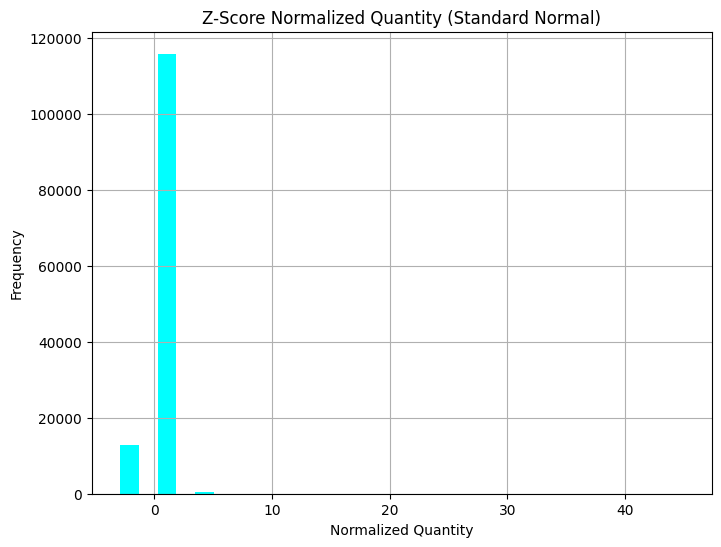

In [17]:
# Apply on Quantity
scaler_z = StandardScaler()
df['Quantity_normalized'] = scaler_z.fit_transform(df[['Qty']])

# Visualization: Histogram showing standard normal shape
plt.figure(figsize=(8, 6))
df['Quantity_normalized'].hist(bins=30, color='cyan')
plt.title('Z-Score Normalized Quantity (Standard Normal)')
plt.xlabel('Normalized Quantity')
plt.ylabel('Frequency')
plt.show()

Percentiles for Amount:
0.10     363.0
0.25     459.0
0.50     605.0
0.75     771.0
0.90    1033.0
Name: Amount, dtype: float64


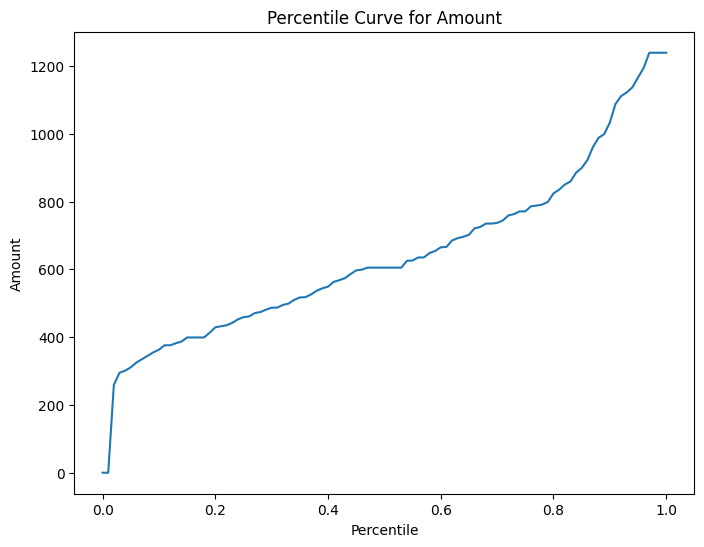

In [18]:
# Compute percentiles for Amount
percentiles = df['Amount'].quantile([0.10, 0.25, 0.50, 0.75, 0.90])
print("Percentiles for Amount:")
print(percentiles)

# Visualization: Percentile curve (cumulative distribution)
plt.figure(figsize=(8, 6))
df['Amount'].quantile(np.arange(0, 1.01, 0.01)).plot()
plt.title('Percentile Curve for Amount')
plt.xlabel('Percentile')
plt.ylabel('Amount')
plt.show()

Columns to encode: ['Category', 'Fulfilment']


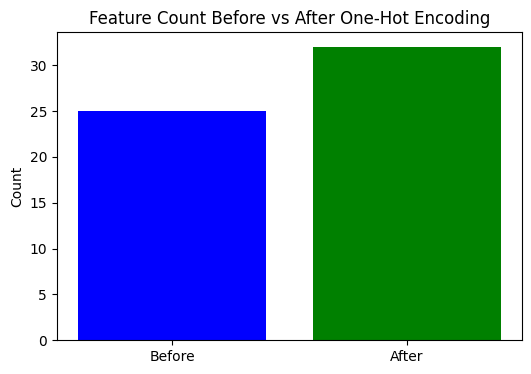

In [20]:
# Apply on Category, Fulfilment, Sales Channel (only if they exist)
cols_to_encode = [col for col in ['Category', 'Fulfilment', 'Sales Channel'] if col in df.columns]
print(f"Columns to encode: {cols_to_encode}")

df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Visualization: Feature count increase
before_enc = len(df.columns)
after_enc = len(df_encoded.columns)
plt.figure(figsize=(6, 4))
plt.bar(['Before', 'After'], [before_enc, after_enc], color=['blue', 'green'])
plt.title('Feature Count Before vs After One-Hot Encoding')
plt.ylabel('Count')
plt.show()

df = df_encoded  # Update df

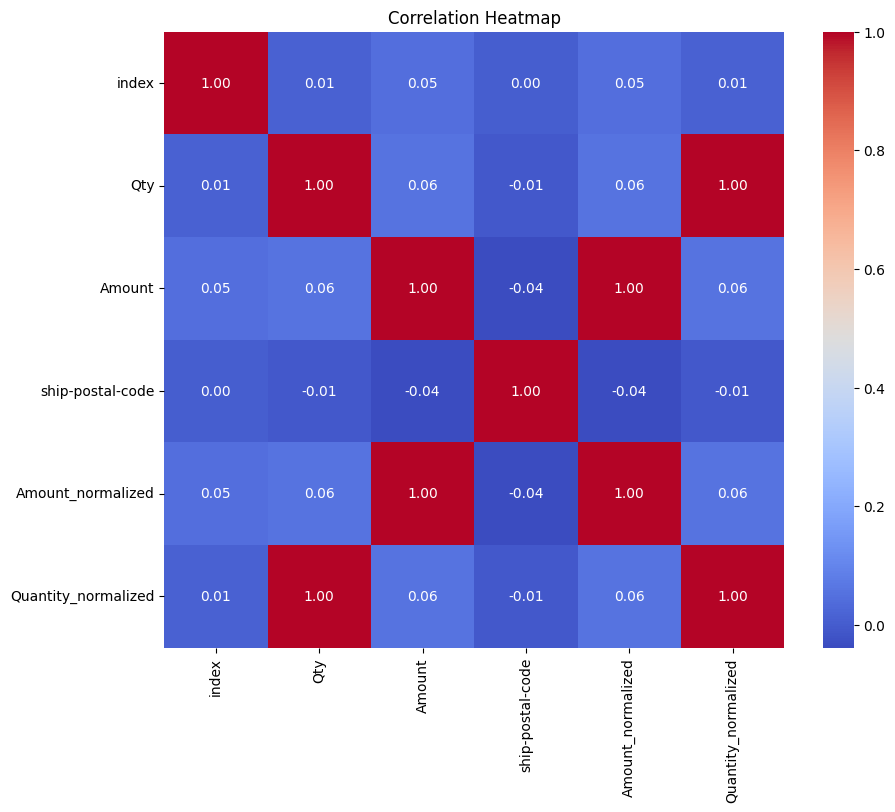

In [21]:
# Pearson correlation (numerical only)
numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Visualization: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

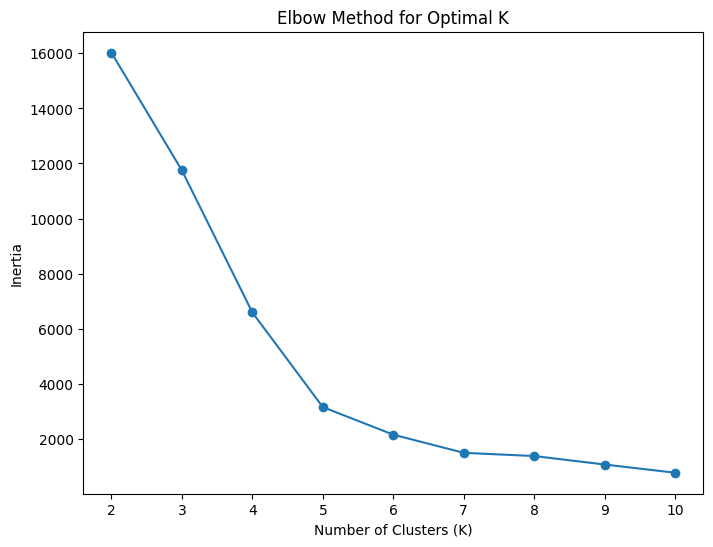

In [22]:
# Test K = 2 to 10 on numerical features (e.g., Amount_normalized, Quantity_normalized)
features = df[['Amount_normalized', 'Quantity_normalized']]
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

# Visualization: Elbow curve
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

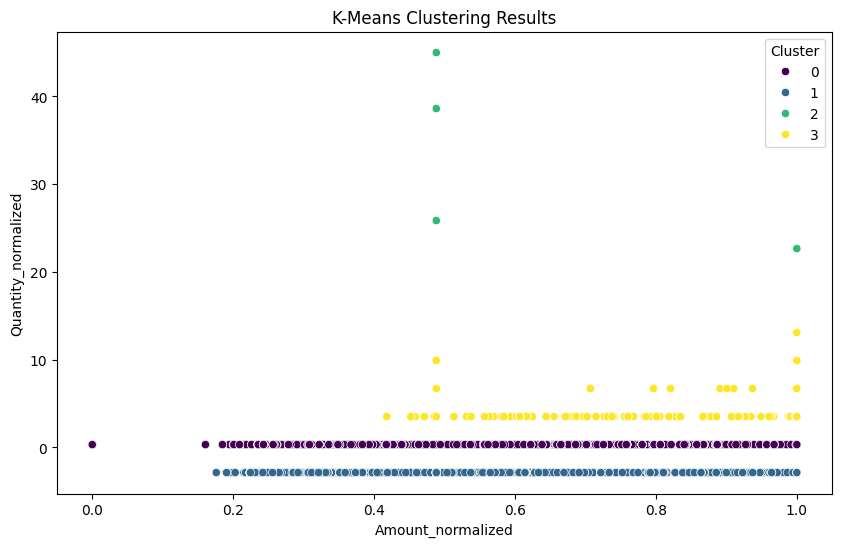

In [23]:
# Assume optimal K=4 from elbow (adjust based on plot)
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(features)

# Visualize clusters (scatter plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Amount_normalized', y='Quantity_normalized', hue='Cluster', data=df, palette='viridis')
plt.title('K-Means Clustering Results')
plt.show()